___
___
# **🧭 Orquestacion de Entrenamiento - Fraud Challenge 2026**
___
___

1. Resolver el cache y controlar si se entrena de nuevo.
2. Cargar los runs y comparar PR-AUC en VALID.
3. Leer curvas, scores e importancia nativa de los modelos que la exponen.
4. Promover el candidato elegido, revisar calibracion y cuantificar la ganancia economica.

In [1]:
# Opcional: site-packages del virtualenv de poetry si el kernel no lo trae (se ignora si no existe).
#   poetry run python -c 'import site; print(site.getsitepackages()[0])'
import sys
from pathlib import Path

POETRY_SITE_PACKAGES = r'C:\Users\JMAB\.venvs\fraud-challenge-x_jSoPDy-py3.11'
if Path(POETRY_SITE_PACKAGES).exists() and POETRY_SITE_PACKAGES not in sys.path:
    sys.path.insert(0, POETRY_SITE_PACKAGES)

In [ ]:
import json
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

DATA_ROOT = Path(os.environ.get("FRAUD_DATA_ROOT", PROJECT_ROOT / "data"))
CONFIGS_ROOT = PROJECT_ROOT / "configs"
ARTIFACTS_ROOT = PROJECT_ROOT / "artifacts"
RUNS_ROOT = ARTIFACTS_ROOT / "runs"
PROMOTED_ROOT = ARTIFACTS_ROOT / "promoted"

# Permite cargar los .pkl guardados de runs previos al aplanado de src/ (ver src/compat.py).
from compat import install_legacy_pickle_aliases

install_legacy_pickle_aliases()

import catboost
import onnxruntime
import torch

from data.manifest import DatasetManifest
from features.cache import FeatureCacheBuilder
from features.schema import load_feature_version
from evaluation.plots import (
    configure_plot_style,
    plot_candidate_pr_roc,
    plot_economic_gain_curve,
    plot_feature_importance,
    plot_reliability_comparison,
    plot_training_curves,
    plot_training_history,
    save_figure,
)
from models.registry import MODEL_REGISTRY
from promotion import promote_winner
from training.runner import ExperimentRunner

configure_plot_style()

print("OK, catboost:", catboost.__version__, "| torch:", torch.__version__, "| onnxruntime:", onnxruntime.__version__)
print("modelos v1:", list(MODEL_REGISTRY["v1"]))

___
___
## **🎛️ 1. Parametros y Flags de Control**

El experimento siempre usa estas cuatro versiones explicitas. Cambiar `model` recorre el mismo cache; cambiar `feature_version` exige un cache nuevo.

| Flag | Efecto |
|---|---|
| `TRAIN_ALL` | `True` entrena los 10 candidatos de `MODEL_REGISTRY`; `False` (por defecto) **salta el entrenamiento** y usa los runs ya guardados |
| `TRAIN_ONE` | `True` entrena solo `model` (para depurar/reintentar un candidato) |
| `INSPECT_MODEL` | modelo a detallar en la celda de resultados individuales (`None` = el mejor por PR-AUC) |
| `PROMOTE_MODEL` | modelo a promover (por defecto `"gradient_boosting"`, que soporta la cadena ONNX; `None` = el mejor por PR-AUC) |
| `PROMOTE` / `FORCE_PROMOTE` | `FORCE_PROMOTE=True` rehace calibracion/ONNX/TEST aunque ya exista `artifacts/promoted/<run_id>/` |

In [ ]:
# Flags
TRAIN_ALL     = False                # True = reentrenar todos los candidatos; False = usar artifacts/runs
TRAIN_ONE     = False                # True = entrenar solo `model`
INSPECT_MODEL = None                 # p. ej. 'catboost'; None = mejor modelo
PROMOTE_MODEL = 'gradient_boosting'  # soporta la cadena ONNX; None = mejor PR-AUC de validacion
PROMOTE       = True
FORCE_PROMOTE = False

# Versiones del Experimento
feature_version         = 'v1'
model_version           = 'v1'
hyperparameters_version = 'v2'
model                   = 'dummy'  # solo lo usa TRAIN_ONE; ver MODEL_REGISTRY[model_version].keys()

assert model_version in MODEL_REGISTRY, f'model_version desconocida: {model_version}'
assert model in MODEL_REGISTRY[model_version], f'modelo desconocido: {model}'

hp_path = CONFIGS_ROOT / 'hyperparameter_versions' / hyperparameters_version / f'{model}.yml'
assert hp_path.exists(), f'No existe YAML de hiperparametros: {hp_path}'
print('OK:', model_version, hyperparameters_version, model, '| TRAIN_ALL =', TRAIN_ALL, '| TRAIN_ONE =', TRAIN_ONE)

OK: v1 v2 dummy | TRAIN_ALL = False | TRAIN_ONE = False


___
___
## **🧱 2. Resolver (o construir) el Cache de Features**

In [ ]:
manifest       = DatasetManifest.from_json(DATA_ROOT / 'processed' / 'manifest.json')
feature_config = load_feature_version(CONFIGS_ROOT / 'feature_versions' / f'{feature_version}.yml')
cache_root     = DATA_ROOT / 'cache' / 'features'

parquet_path = Path(manifest.output_parquet.path)
cache_paths  = FeatureCacheBuilder().build(parquet_path, manifest, feature_version, feature_config, cache_root)
print('Cache Resuelto en:', cache_paths.root)
print(cache_paths.load_metadata())

[FeatureCacheBuilder] cache hit: /alloc/data/fury_ads-ctr-item-trigger-fda/fraud_challenge_2026/data/cache/features/v1/fb98053521f0507f
cache resuelto en: /alloc/data/fury_ads-ctr-item-trigger-fda/fraud_challenge_2026/data/cache/features/v1/fb98053521f0507f
{'feature_cache_id': 'fb98053521f0507f', 'feature_version': 'v1', 'created_at': '2026-10-05T03:05:55.583330+00:00', 'parquet_hash': 'b54b10e97e6021dc7c27d875cd79c32d51ca5a0a6c3a2e3941420522c60b9801', 'split_manifest_hash': '4d72632f136ccd925586066474f4c16f308872621d987f7156760ba4a36f807e', 'feature_yaml_hash': 'ad226a2c2407d70f7271316935ab88f5aac42953979518558dc04107f9b1f20b', 'code_version': '1', 'dependency_versions': {'scikit-learn': '1.4.2', 'category_encoders': '2.7.0', 'pandas': '2.3.3', 'numpy': '1.26.4', 'scipy': '1.12.0'}, 'row_counts': {'TRAIN': 97243, 'VALID': 23771, 'TEST': 28986}, 'prevalence': {'TRAIN': 0.051623253087625845, 'VALID': 0.05224853813470195, 'TEST': 0.04271027392534327}, 'is_sparse': False, 'n_features': 3

___
___
## **🏋️ 3. Entrenar un Candidato**

In [ ]:
if TRAIN_ONE:
    runner = ExperimentRunner(
        feature_version         = feature_version,
        model_version           = model_version,
        hyperparameters_version = hyperparameters_version,
        model                   = model,
        seed                    = 42,
        data_root               = DATA_ROOT,
        configs_root            = CONFIGS_ROOT,
        artifacts_root          = ARTIFACTS_ROOT,
    )
    result = runner.run()
    print(
        f'🚀 Resultados del Entrenamiento:\n'
        f'   ├─ Run ID            : {result.run_id}\n'
        f'   ├─ Mejor Época       : {result.best_epoch}\n'
        f'   └─ Mejor Valid PR-AUC: {result.best_valid_pr_auc:.4f}'
    )
else:
    print('TRAIN_ONE = False: Se salta el entrenamiento individual.')

[dummy] fit() sin epochs (un solo llamado bloqueante) - iniciando...
[dummy] fit() termino en 0.0s
epoch=final train_pr_auc=0.0516 valid_pr_auc=0.0522 (tardo 0.4s)
run_id: dummy-v1-v2-v1-seed42-20261005T030603-84266041
best_epoch: final | best_valid_pr_auc: 0.05224853813470195


___
### **3.1 Entrenar todos los candidatos v1 (opcional)**

- Con `TRAIN_ALL = True` recorre `MODEL_REGISTRY["v1"]` completo (*los 10 modelos*) con la misma `feature_version`/`hyperparameters_version`: todos comparan exactamente el mismo cache. `mlp`/`dcnv2`/`ft_transformer` corren en CPU y pueden tardar varios minutos cada uno (*el total fue ~35 min*). Si un modelo falla, el bucle sigue con el siguiente.
- Con `TRAIN_ALL = False` (*por defecto*) **la celda no entrena nada**: los resultados se leen de `artifacts/runs/` en la celda `load_all_runs()` de abajo.

**Progreso:** los modelos con epochs (`mlp`, `dcnv2`, `ft_transformer`) muestran barra con % y ETA; los de un solo `fit` imprimen cuando arrancan y cuanto tardaron; `catboost` imprime su progreso nativo.

In [ ]:
if TRAIN_ALL:
    from tqdm.auto import tqdm

    for candidate_model in tqdm(list(MODEL_REGISTRY[model_version]), desc = 'Candidatos', unit = 'modelo'):
        print(f'=== Entrenando: {candidate_model} ===')
        start = time.perf_counter()
        try:
            candidate_result = ExperimentRunner(
                feature_version         = feature_version,
                model_version           = model_version,
                hyperparameters_version = hyperparameters_version,
                model                   = candidate_model,
                seed                    = 42,
                data_root               = DATA_ROOT,
                configs_root            = CONFIGS_ROOT,
                artifacts_root          = ARTIFACTS_ROOT,
            ).run()
            print(f'    OK ({time.perf_counter() - start:.1f}s) best_valid_pr_auc={candidate_result.best_valid_pr_auc:.4f}')
        except Exception as exc:
            print(f'    FALLO {candidate_model} ({time.perf_counter() - start:.1f}s): {exc}')
else:
    print('TRAIN_ALL = False: Entrenamiento omitido, se usan los runs guardados en', RUNS_ROOT)

Candidatos:   0%|          | 0/10 [00:00<?, ?modelo/s]

=== Entrenando: dummy ===
[dummy] fit() sin epochs (un solo llamado bloqueante) - iniciando...
[dummy] fit() termino en 0.0s


Candidatos:  10%|█         | 1/10 [00:00<00:04,  1.81modelo/s]

epoch=final train_pr_auc=0.0516 valid_pr_auc=0.0522 (tardo 0.4s)
    OK (0.6s) best_valid_pr_auc=0.0522
=== Entrenando: logistic_regression ===
[logistic_regression] fit() sin epochs (un solo llamado bloqueante) - iniciando...
[logistic_regression] fit() termino en 1.7s


Candidatos:  20%|██        | 2/10 [00:02<00:13,  1.66s/modelo]

...

    OK (109.9s) best_valid_pr_auc=0.4191
=== Entrenando: dcnv2 ===



Candidatos:  90%|█████████ | 9/10 [08:42<01:21, 81.26s/modelo]/alloc/data/fury_ads-ctr-item-trigger-fda/fraud_challenge_2026/src/models/versions/v1/ft_transformer.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)


    OK (46.4s) best_valid_pr_auc=0.4282
=== Entrenando: ft_transformer ===



Candidatos: 100%|██████████| 10/10 [34:33<00:00, 207.38s/modelo]

    OK (1551.8s) best_valid_pr_auc=0.4284


___
___
## **📊 4. Comparar los runs Guardados (PR-AUC de validacion)**

`load_all_runs()` lee `artifacts/runs/<run_id>/` (metadata + `metrics/epoch_metrics.parquet`) sin reentrenar. Devuelve:

- `all_runs`  : Todos los runs en disco que coinciden con las versiones del experimento (*incluye repetidos*).
- `comparison`: Un run por modelo (*el mas reciente*), ordenado por `best_valid_pr_auc`. Es la tabla que usan todas las celdas siguientes, con `TRAIN_ALL` en `True` o `False`.

In [ ]:
def load_all_runs(runs_root: Path = RUNS_ROOT):
    rows = []
    for run_dir in sorted(Path(runs_root).glob('*')):
        meta_path    = run_dir / 'model' / 'metadata.json'
        metrics_path = run_dir / 'metrics' / 'epoch_metrics.parquet'
        if not (meta_path.exists() and metrics_path.exists()):
            continue
        meta = json.loads(meta_path.read_text())
        if (meta['feature_version'], meta['model_version'], meta['hyperparameters_version']) != (
            feature_version, model_version, hyperparameters_version,
        ):
            continue
        df      = pd.read_parquet(metrics_path)
        best    = df.loc[df['valid.average_precision'].astype(float).idxmax()]
        seconds = df['cumulative_seconds'].dropna().max() if 'cumulative_seconds' in df else np.nan
        rows.append({
            'model'            : meta['model'],
            'run_id'           : meta['run_id'],
            'created_at'       : meta['created_at'],
            'best_epoch'       : best['epoch'],
            'n_epochs'         : len(df),
            'best_valid_pr_auc': float(best['valid.average_precision']),
            'valid_roc_auc'    : float(best['valid.roc_auc']),
            'valid_brier'      : float(best['valid.brier']),
            'valid_ece'        : float(best['valid.ece']),
            'valid_ks'         : float(best['valid.ks']),
            'train_pr_auc'     : float(best['train.average_precision']),
            'gap_pr_auc'       : float(best['generalization_gap_pr_auc']) if 'generalization_gap_pr_auc' in best else np.nan,
            'train_seconds'    : float(seconds) if pd.notna(seconds) else np.nan,
        })
    all_runs = pd.DataFrame(rows)
    if all_runs.empty:
        return all_runs, all_runs
    latest     = all_runs.sort_values('created_at').drop_duplicates('model', keep='last')
    comparison = latest.sort_values('best_valid_pr_auc', ascending = False).reset_index(drop=True)
    return all_runs, comparison


all_runs, comparison = load_all_runs()
assert len(comparison) > 0, 'No hay runs en artifacts/runs: pon TRAIN_ALL = True y vuelve a correr.'
print(f'{len(all_runs)} runs en disco, {len(comparison)} modelos distintos (se usa el run mas reciente de cada uno)')
display(comparison.drop(columns = ['created_at']).round(4))

11 runs en disco, 10 modelos distintos (se usa el run mas reciente de cada uno)


,model,run_id,best_epoch,n_epochs,best_valid_pr_auc,valid_roc_auc,valid_brier,valid_ece,valid_ks,train_pr_auc,gap_pr_auc,train_seconds
0,hist_gradient_boosting,hist_gradient_boosting-v1-v2-v1-seed42-2026100...,final,1,0.4335,0.8683,0.1050,0.1775,0.5793,0.5769,0.1434,NaN
1,stacking_ensemble,stacking_ensemble-v1-v2-v1-seed42-20261005T030...,final,1,0.4310,0.8691,0.0392,0.0172,0.5787,0.5766,0.1455,NaN
2,gradient_boosting,gradient_boosting-v1-v2-v1-seed42-20261005T030...,final,1,0.4286,0.8693,0.1102,0.1928,0.5815,0.5414,0.1128,NaN
3,ft_transformer,ft_transformer-v1-v2-v1-seed42-20261005T031449...,15,23,0.4284,0.8742,0.1344,0.2154,0.5925,0.5120,0.0836,1411.9612
4,dcnv2,dcnv2-v1-v2-v1-seed42-20261005T031402-e6e3159f,11,21,0.4282,0.8617,0.1142,0.2053,0.5675,0.5144,0.0862,32.8548
5,mlp,mlp-v1-v2-v1-seed42-20261005T031212-46dc70ee,19,29,0.4191,0.8528,0.1165,0.1870,0.5481,0.5230,0.1039,86.5623
6,catboost,catboost-v1-v2-v1-seed42-20261005T030758-f9936fed,final,1,0.4174,0.8682,0.1150,0.2094,0.5806,0.5212,0.1038,NaN
7,voting_ensemble,voting_ensemble-v1-v2-v1-seed42-20261005T03080...,final,1,0.4146,0.8619,0.1061,0.1986,0.5697,0.5561,0.1415,NaN
8,logistic_regression,logistic_regression-v1-v2-v1-seed42-20261005T0...,final,1,0.2044,0.7498,0.1591,0.2892,0.4076,0.2888,0.0844,NaN
9,dummy,dummy-v1-v2-v1-seed42-20261005T030607-84266041,final,1,0.0522,0.5000,0.0495,0.0006,0.0000,0.0516,-0.0006,NaN


___
___
## **🔎 5. Resultados Individuales de un Modelo**

Cambia `INSPECT_MODEL` o llama `inspect_run("catboost")`. Muestra todo lo que se guarda por corrida: hiperparametros, metricas train vs valid en el mejor epoch, metricas por umbral y por top-k, matriz de confusion, pesos de ensembles y curvas de entrenamiento.

In [ ]:
def inspect_run(model_name: str | None = None):
    row       = comparison.iloc[0] if model_name is None else comparison[comparison['model'] == model_name].iloc[0]
    run_dir   = RUNS_ROOT / row['run_id']
    meta      = json.loads((run_dir / 'model' / 'metadata.json').read_text())
    history   = json.loads((run_dir / 'metrics' / 'epoch_metrics.json').read_text())
    epochs_df = pd.read_parquet(run_dir / 'metrics' / 'epoch_metrics.parquet')
    record    = history[str(row['best_epoch'])]

    display(Markdown(f"### {row['model']} - `{row['run_id']}`"))
    print(f"best_epoch={row['best_epoch']} de {row['n_epochs']} | git_sha={meta['git_sha'][:8]} | seed={meta['seed']} | feature_cache_id={meta['feature_cache_id']}")

    display(Markdown('**Hiperparametros**'))
    print(json.dumps(meta['hyperparameters'], indent=2))

    scalar_keys = [k for k, v in record['valid'].items() if not isinstance(v, (dict, list))]
    display(Markdown('**Metricas en el mejor epoch (train vs valid)**'))
    display(pd.DataFrame({
        'train': {k: record['train'].get(k) for k in scalar_keys},
        'valid': {k: record['valid'][k] for k in scalar_keys},
    }))

    for key, title in [('by_threshold', 'por umbral'), ('by_top_k', 'por top-k %')]:
        if isinstance(record['valid'].get(key), dict):
            display(Markdown(f'**VALID {title}**'))
            display(pd.DataFrame.from_dict(record['valid'][key], orient='index'))

    cm = record['valid']
    print(f"Matriz de Confusion VALID: TP={cm['tp']} FP={cm['fp']} TN={cm['tn']} FN={cm['fn']}")

    best_row = epochs_df.loc[epochs_df['valid.average_precision'].astype(float).idxmax()]
    extra = best_row[[c for c in epochs_df.columns if c.startswith(('stacking_meta_coefficients.', 'voting_weights'))]].dropna()
    if len(extra):
        display(Markdown('**Pesos / coeficientes del ensemble**'))
        display(extra.to_frame('valor'))

    fig = plot_training_history(epochs_df, row['best_epoch'], row['model'])
    if fig is not None:
        plt.show()
        plt.close(fig)
    else:
        print('Modelo de un solo Fit: no hay curva por epoch.')
    return epochs_df

#INSPECT_MODEL = None                 # p. ej. 'catboost'; None = mejor modelo
_ = inspect_run(INSPECT_MODEL)

### hist_gradient_boosting - `hist_gradient_boosting-v1-v2-v1-seed42-20261005T030610-eb761a4e`

best_epoch=final de 1 | git_sha=a6c5ff26 | seed=42 | feature_cache_id=fb98053521f0507f


**Hiperparametros**

{
  "parameters": {
    "max_iter": 300,
    "learning_rate": 0.05,
    "max_leaf_nodes": 31,
    "class_weight": "balanced",
    "early_stopping": true,
    "n_iter_no_change": 20
  }
}


**Metricas en el mejor epoch (train vs valid)**

...

**VALID por umbral**

,tp,fp,tn,fn,precision,recall,f1,f_beta,specificity,fpr,fnr
0.1,1154,11139,11390,88,0.093875,0.929147,0.170521,0.334280,0.505571,0.494429,0.070853
0.25,1051,6457,16072,191,0.139984,0.846216,0.240229,0.421209,0.713392,0.286608,0.153784
0.5,878,3241,19288,364,0.213159,0.706924,0.327551,0.483108,0.856141,0.143859,0.293076
0.75,630,1219,21310,612,0.340725,0.507246,0.407635,0.462080,0.945892,0.054108,0.492754
0.9,367,227,22302,875,0.617845,0.295491,0.399782,0.329917,0.989924,0.010076,0.704509


**VALID por top-k %**

,precision_at_k,recall_at_k,capture_rate_at_k,lift_at_k
0.5,0.890756,0.085346,0.085346,17.048444
1,0.794118,0.152174,0.152174,15.198849
2,0.677895,0.259259,0.259259,12.974425
5,0.436501,0.417874,0.417874,8.354325
10,0.296592,0.567633,0.567633,5.676567


Matriz de confusion VALID: TP=878 FP=3241 TN=19288 FN=364
Modelo de un solo fit: no hay curva por epoch.


___
### *5.1 Curvas de Entrenamiento*

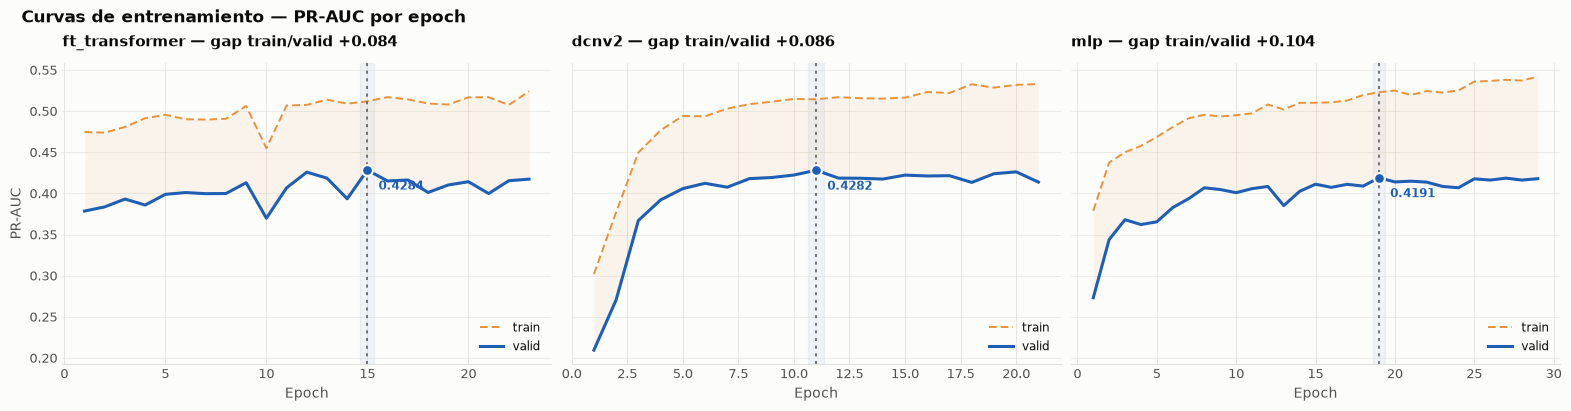

In [ ]:
curves_by_model = {
    row['model']: pd.read_parquet(RUNS_ROOT / row['run_id'] / 'metrics' / 'epoch_metrics.parquet')
    for _, row in comparison[comparison['n_epochs'] > 1].iterrows()
}

fig = plot_training_curves(comparison, curves_by_model)
if fig is not None:
    plt.show()
    plt.close(fig)

___
___
## **📈 6. Curvas PR y ROC de los Candidatos**

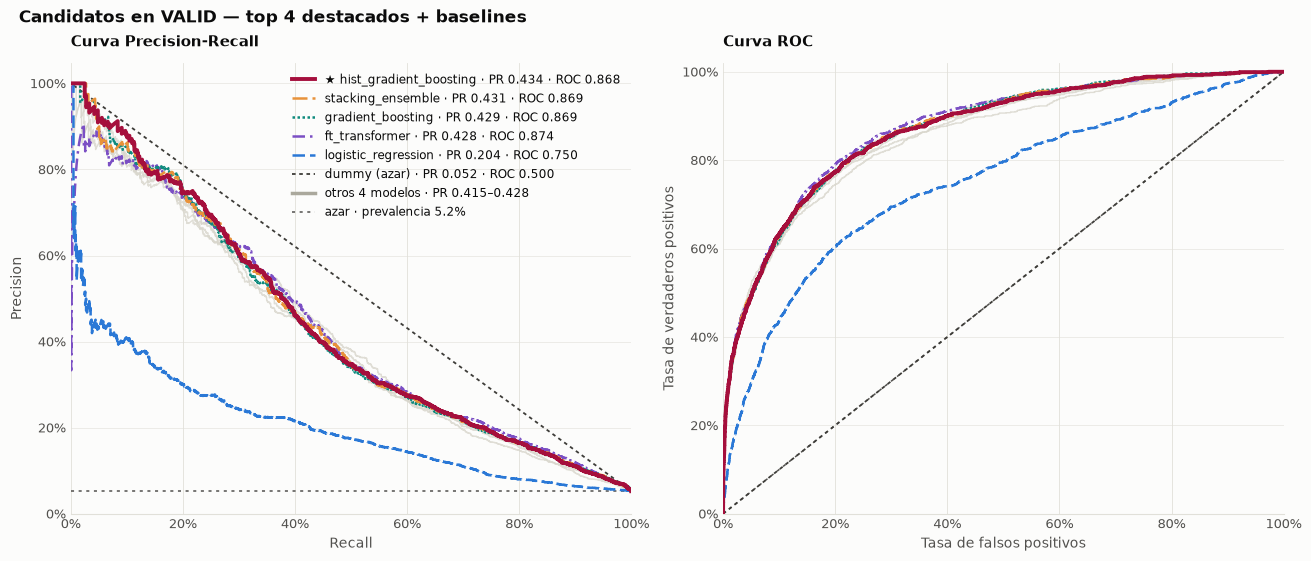

In [ ]:
from sklearn.metrics import average_precision_score, roc_auc_score

def load_best_valid_scores(run_id: str, best_epoch):
    path = ARTIFACTS_ROOT / 'runs' / run_id / 'predictions' / 'valid_scores_by_epoch.npz'
    data = np.load(path)
    return data[f'epoch_{best_epoch}_y_true'], data[f'epoch_{best_epoch}_y_score']

results = []
for _, row in comparison.iterrows():
    try:
        y_true, y_score = load_best_valid_scores(row['run_id'], row['best_epoch'])
    except (FileNotFoundError, KeyError) as exc:
        print(f"Omitido {row['model']}: {exc}")
        continue
    results.append({
        'model'  : row['model'], 'y_true': y_true, 'y_score': y_score,
        'pr_auc' : average_precision_score(y_true, y_score),
        'roc_auc': roc_auc_score(y_true, y_score),
    })
results.sort(key=lambda d: d['pr_auc'], reverse=True)


plot_result = plot_candidate_pr_roc(results, top_n = 4)
if plot_result is not None:
    fig, results = plot_result
    save_figure(fig, ARTIFACTS_ROOT / 'comparacion_pr_roc.png')
    plt.show()
    plt.close(fig)

___
___
## **📦 7. Acceder a los Artefactos Guardados de cada Corrida**

In [ ]:
# Reliability/curvas con los scores crudos por epoch (predictions/*_scores_by_epoch.npz): guarda y_true/y_score de train y valid en cada epoch, util para recalcular curvas PR/ROC, calibracion o umbrales sin reentrenar.
def load_epoch_scores(run_id: str, split: str = 'valid'):
    path = ARTIFACTS_ROOT / 'runs' / run_id / 'predictions' / f'{split}_scores_by_epoch.npz'
    data = np.load(path)
    return {k: data[k] for k in data.files}

# Ejemplo:
# scores = load_epoch_scores(comparison.iloc[0]['run_id'], split='valid')
# sorted(scores.keys())[:4]

In [ ]:
# Recargar un modelo ya entrenado (para inspeccionar, predecir sobre datos nuevos, o exportar):
import json as _json
from models.registry import MODEL_REGISTRY

def load_trained_model(run_id: str):
    run_dir     = ARTIFACTS_ROOT / 'runs' / run_id
    metadata    = _json.loads((run_dir / 'model' / 'metadata.json').read_text())
    model_class = MODEL_REGISTRY[metadata['model_version']][metadata['model']]
    return model_class.load(run_dir / 'model' / metadata['model_filename']), metadata

# Ejemplo:
# model, metadata = load_trained_model(comparison.iloc[0]['run_id'])
# model.predict_proba(X_valid)  # X_valid sale de cache_paths.load_split('valid') (celda de cache)

___
___
## **🧠 8. Importancia de Variables por Modelo**

/alloc/data/fury_ads-ctr-item-trigger-fda/fraud_challenge_2026/src/models/versions/v1/ft_transformer.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)


### Top de variables por modelo

,model,method,variable,importance,importance_pct
17,catboost,get_feature_importance(),score,30.9239,30.9239
15,catboost,get_feature_importance(),o,28.0339,28.0339
9,catboost,get_feature_importance(),j,23.7266,23.7266
7,catboost,get_feature_importance(),g,4.1078,4.1078
6,catboost,get_feature_importance(),fecha,2.5216,2.5216
11,catboost,get_feature_importance(),l,2.2407,2.2407
5,catboost,get_feature_importance(),f,2.1543,2.1543
12,catboost,get_feature_importance(),m,1.2462,1.2462
14,catboost,get_feature_importance(),n,0.9753,0.9753
1,catboost,get_feature_importance(),b,0.7534,0.7534


### Detalle de features transformadas

,model,feature,variable,importance,importance_pct,coefficient,direction
0,gradient_boosting,o,o,0.3534,35.3380,NaN,NaN
1,gradient_boosting,j,j,0.2908,29.0847,NaN,NaN
2,gradient_boosting,score,score,0.2588,25.8781,NaN,NaN
3,gradient_boosting,g__BR,g,0.0207,2.0665,NaN,NaN
4,gradient_boosting,f,f,0.0174,1.7430,NaN,NaN
5,gradient_boosting,l,l,0.0157,1.5686,NaN,NaN
6,gradient_boosting,m_0,m,0.0076,0.7570,NaN,NaN
7,gradient_boosting,n,n,0.0066,0.6630,NaN,NaN
8,gradient_boosting,monto,monto,0.0041,0.4101,NaN,NaN
9,gradient_boosting,c_0,c,0.0035,0.3506,NaN,NaN


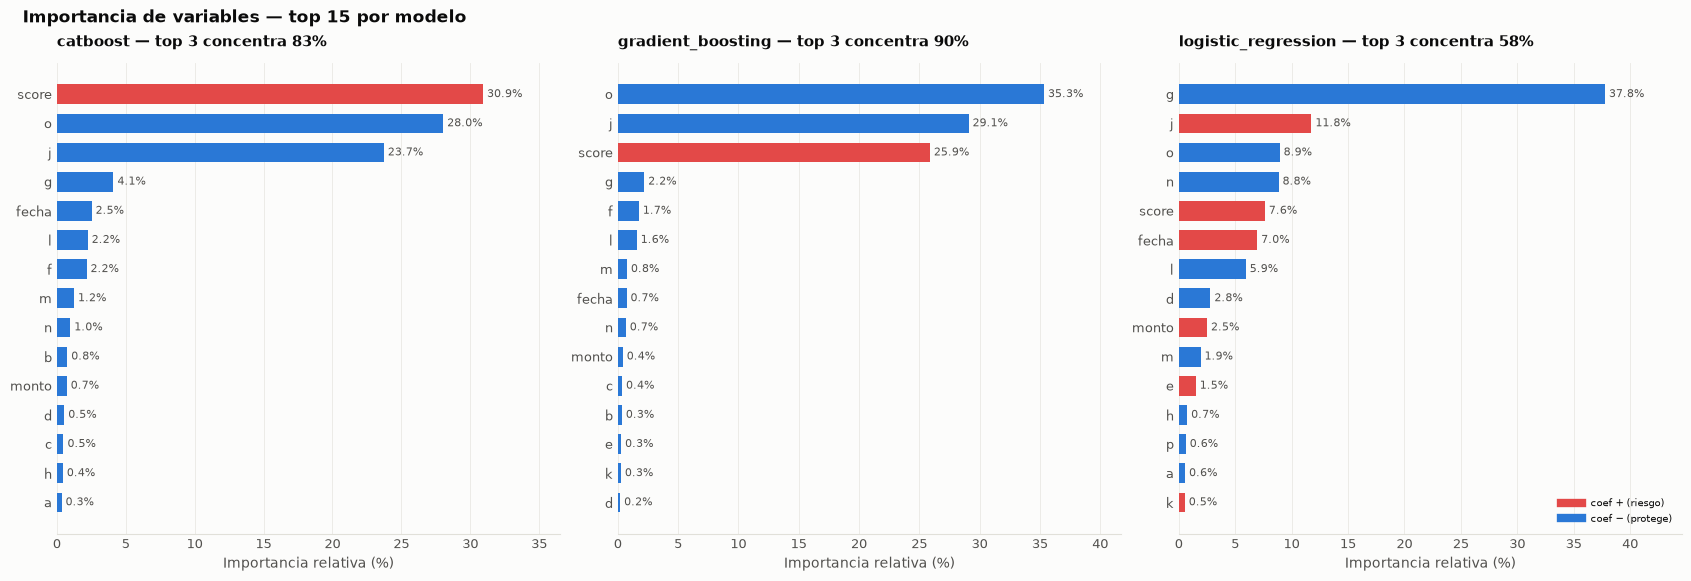

### Modelos omitidos

,motivo
hist_gradient_boosting,sin importancia nativa
stacking_ensemble,sin importancia nativa
ft_transformer,sin importancia nativa
dcnv2,sin importancia nativa
mlp,sin importancia nativa
voting_ensemble,sin importancia nativa
dummy,sin importancia nativa


In [ ]:
import re
def _importance_table(model_instance):
    estimator = getattr(model_instance, 'estimator', None)
    feature_names = np.asarray(getattr(model_instance, 'feature_names', []), dtype=str)
    if estimator is None:
        return None, None

    signed = None
    if hasattr(estimator, 'coef_'):
        signed = np.asarray(estimator.coef_).reshape(-1)
        values = np.abs(signed)
        method = 'abs(coef_)'
    elif hasattr(estimator, 'get_feature_importance'):
        values = np.asarray(estimator.get_feature_importance()).reshape(-1)
        method = 'get_feature_importance()'
    elif hasattr(estimator, 'feature_importances_'):
        values = np.asarray(estimator.feature_importances_).reshape(-1)
        method = 'feature_importances_'
    else:
        return None, None

    if len(feature_names) != len(values):
        return None, f'{len(values)} Importancias para {len(feature_names)} Nombres'

    table = pd.DataFrame({
        'feature'    : feature_names,
        'importance' : values.astype(float),
        'coefficient': signed.astype(float) if signed is not None else np.nan,
        'direction'  : np.where(signed >= 0, 'positiva', 'negativa') if signed is not None else np.nan,
    })
    table['variable'] = table['feature'].map(
        lambda name: name.split('__', 1)[0] if '__' in name else re.sub(r'_\d+$', '', name)
    )
    total = table['importance'].sum()
    table['importance_pct'] = 100 * table['importance'] / total if total else 0.0
    return table.sort_values('importance', ascending=False).reset_index(drop=True), method


importance_tables  = []
skipped_importance = {}
for _, row in comparison.iterrows():
    model_name = row['model']
    try:
        model_instance, _ = load_trained_model(str(row['run_id']))
        table, method_or_reason = _importance_table(model_instance)
    except Exception as exc:
        table, method_or_reason = None, str(exc)
    if table is None:
        skipped_importance[model_name] = method_or_reason or 'sin importancia nativa'
        continue
    table.insert(0, 'method', method_or_reason)
    table.insert(0, 'model', model_name)
    importance_tables.append(table)

if importance_tables:
    all_importances = pd.concat(importance_tables, ignore_index=True)
    # Agregacion por variable original; si hay coeficientes, la direccion dominante
    # es la de mayor |coef| entre las features derivadas de esa variable
    variable_importances = (
        all_importances.groupby(['model', 'method', 'variable'], as_index=False)
        .agg(importance=('importance', 'sum'), dominant_coef=('coefficient', lambda s: s.loc[s.abs().idxmax()] if s.notna().any() else np.nan))
    )
    variable_importances['importance_pct'] = (
        variable_importances['importance']
        / variable_importances.groupby('model')['importance'].transform('sum')
        * 100
    )
    variable_importances = variable_importances.sort_values(
        ['model', 'importance'], ascending=[True, False]
    )

    display(Markdown('### Top de Variables por Modelo'))
    display(
        variable_importances.groupby('model', sort=False).head(20)[
            ['model', 'method', 'variable', 'importance', 'importance_pct']
        ].round(4)
    )

    display(Markdown('### Detalle de Features Transformadas'))
    display(
        all_importances.groupby('model', sort=False).head(20)[
            ['model', 'feature', 'variable', 'importance', 'importance_pct', 'coefficient', 'direction']
        ].round(4)
    )

    fig = plot_feature_importance(
        variable_importances,
        top_k=15,
        flagged={'score'},
    )
    save_figure(fig, ARTIFACTS_ROOT / 'importancia_variables.png')
    plt.show()
    plt.close(fig)
else:
    print('Ningun run expone importancia nativa.')

if skipped_importance:
    display(Markdown('### Modelos Omitidos'))
    display(pd.Series(skipped_importance, name = 'motivo').to_frame())

___
___
## **🚀 9. Promover el Ganador: Calibracion y Politica Economica**

- La promocion calibra sus scores (*Platt/auto*), exporta `ONNX`, congela el umbral segun `economic_profit` y evalua TEST una sola vez.
- Si `artifacts/promoted/<run_id>/model_card.md` ya existe y `FORCE_PROMOTE = False`, la celda **no repite nada** y reutiliza lo guardado.

In [ ]:
if PROMOTE_MODEL is None:
    winner_run_id = str(comparison.iloc[0]['run_id'])
else:
    candidates = comparison[comparison['model'] == PROMOTE_MODEL]
    assert len(candidates) == 1, f"{PROMOTE_MODEL} no esta en comparison: {list(comparison['model'])}"
    winner_run_id = str(candidates.iloc[0]['run_id'])

promoted_dir = PROMOTED_ROOT / winner_run_id
if (promoted_dir / 'model_card.md').exists() and not FORCE_PROMOTE:
    print('YA PROMOVIDO, SE REUTILIZAN LOS ARTEFACTOS:', promoted_dir)
elif PROMOTE:
    print('Promoviendo:', winner_run_id)
    promoted_dir = promote_winner(
        runs_dir               = RUNS_ROOT,
        config_path            = CONFIGS_ROOT / 'promotion' / 'v1.yml',
        data_root              = DATA_ROOT,
        configs_root           = CONFIGS_ROOT,
        promoted_root          = PROMOTED_ROOT,
        override_winner_run_id = winner_run_id,
        force_test_rerun       = FORCE_PROMOTE,
    )
    print('ARTEFACTOS PROMOVIDOS EN:', promoted_dir)
else:
    raise RuntimeError(f'{winner_run_id} no esta promovido y PROMOTE = False')

Promoviendo: gradient_boosting-v1-v2-v1-seed42-20261005T030618-e4fb98c9
[promote_winner] winner_run_id = gradient_boosting-v1-v2-v1-seed42-20261005T030618-e4fb98c9
[promote_winner] Paridad 1 (modelo .pkl vs model_raw.onnx): OK
[promote_winner] Paridad 2 (calibrator.pkl vs calibrator.onnx): OK
[promote_winner] Paridad 3 (cadena completa): OK
[promote_winner] TEST evaluado una unica vez sobre la cadena ONNX completa.
[promote_winner] Model Card escrito en /alloc/data/fury_ads-ctr-item-trigger-fda/fraud_challenge_2026/artifacts/promoted/gradient_boosting-v1-v2-v1-seed42-20261005T030618-e4fb98c9/model_card.md
Artefactos promovidos en: /alloc/data/fury_ads-ctr-item-trigger-fda/fraud_challenge_2026/artifacts/promoted/gradient_boosting-v1-v2-v1-seed42-20261005T030618-e4fb98c9


___
___
## **📋 10. Todo lo Guardado en la Promocion**

### Comparacion de candidatos (la que uso `promote_winner`)

,run_id,model,model_version,hyperparameters_version,feature_version,valid_pr_auc,valid_roc_auc,valid_brier
0,hist_gradient_boosting-v1-v2-v1-seed42-2026100...,hist_gradient_boosting,v1,v2,v1,0.4335,0.8683,0.1050
1,stacking_ensemble-v1-v2-v1-seed42-20261005T030...,stacking_ensemble,v1,v2,v1,0.4310,0.8691,0.0392
2,gradient_boosting-v1-v2-v1-seed42-20261005T030...,gradient_boosting,v1,v2,v1,0.4286,0.8693,0.1102
3,ft_transformer-v1-v2-v1-seed42-20261005T031449...,ft_transformer,v1,v2,v1,0.4284,0.8742,0.1344
4,dcnv2-v1-v2-v1-seed42-20261005T031402-e6e3159f,dcnv2,v1,v2,v1,0.4282,0.8617,0.1142
5,mlp-v1-v2-v1-seed42-20261005T031212-46dc70ee,mlp,v1,v2,v1,0.4191,0.8528,0.1165
6,catboost-v1-v2-v1-seed42-20261005T030758-f9936fed,catboost,v1,v2,v1,0.4174,0.8682,0.1150
7,voting_ensemble-v1-v2-v1-seed42-20261005T03080...,voting_ensemble,v1,v2,v1,0.4146,0.8619,0.1061
8,logistic_regression-v1-v2-v1-seed42-20261005T0...,logistic_regression,v1,v2,v1,0.2044,0.7498,0.1591
9,dummy-v1-v2-v1-seed42-20261005T030603-84266041,dummy,v1,v2,v1,0.0522,0.5000,0.0495


### Metricas finales en TEST (una sola evaluacion, umbral congelado)

,TEST
average_precision,0.376104
roc_auc,0.854954
gini,0.709909
ks,0.558259
log_loss,0.134005
brier,0.034262
ece,0.013504
accuracy,0.957290
balanced_accuracy,0.500000
mcc,0.000000


,TEST economico
threshold,2.726470e-01
profit_total,2.217249e+05
profit_per_transaction,7.649380e+00
approved_count,2.742800e+04
approved_rate,9.462499e-01
approved_amount,1.107954e+06
fraud_approved_amount,4.421077e+04
legitimate_approved_amount,1.063743e+06
approve_all_profit,1.912472e+05
reject_all_profit,0.000000e+00


...

### Soporte por segmento

,column,value,count,sufficient_support
0,g,BR,17926,True
1,g,AR,4706,True
2,g,UY,542,True
3,g,US,377,True
4,g,SE,61,True
5,g,MX,35,True
6,g,ES,14,False
7,g,RU,11,False
8,g,GB,8,False
9,g,CO,5,False


### Tabla de umbrales (cada ~10 filas)

,threshold,precision,recall,fpr,f1,tp,fp,tn,fn,profit_total,profit_per_transaction,approved_count,approved_rate,approved_amount,fraud_approved_amount,legitimate_approved_amount,approve_all_profit,reject_all_profit,profit_uplift_vs_approve_all
0,0.000000,0.052249,1.000000,1.000000,0.099308,1242,22529,0,0,0.0000,0.000000,0,0.000000,0.00,0.00,0.00,127601.7175,0.0,-127601.7175
10,0.006752,0.052268,1.000000,0.999601,0.099344,1242,22520,9,0,71.8500,0.003023,9,0.000379,287.40,0.00,287.40,127601.7175,0.0,-127529.8675
20,0.006779,0.052293,1.000000,0.999112,0.099388,1242,22509,20,0,135.0100,0.005680,20,0.000841,540.04,0.00,540.04,127601.7175,0.0,-127466.7075
30,0.006786,0.052315,1.000000,0.998668,0.099428,1242,22499,30,0,201.9500,0.008496,30,0.001262,807.80,0.00,807.80,127601.7175,0.0,-127399.7675
40,0.006793,0.052337,1.000000,0.998225,0.099467,1242,22489,40,0,298.0775,0.012540,40,0.001683,1192.31,0.00,1192.31,127601.7175,0.0,-127303.6400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23130,0.458892,0.959184,0.037842,0.000089,0.072812,47,2,22527,1195,132960.4900,5.593391,23722,0.997939,939248.76,81481.36,857767.40,127601.7175,0.0,5358.7725
23140,0.460875,0.948718,0.029791,0.000089,0.057767,37,2,22527,1205,132533.7300,5.575438,23732,0.998359,939675.52,81908.12,857767.40,127601.7175,0.0,4932.0125
23150,0.463505,0.965517,0.022544,0.000044,0.044060,28,1,22528,1214,132111.5675,5.557678,23742,0.998780,941336.22,82577.99,858758.23,127601.7175,0.0,4509.8500
23160,0.464851,1.000000,0.015298,0.000000,0.030135,19,0,22529,1223,130818.0275,5.503261,23752,0.999201,942641.76,83873.93,858767.83,127601.7175,0.0,3216.3100


**pr_curve**

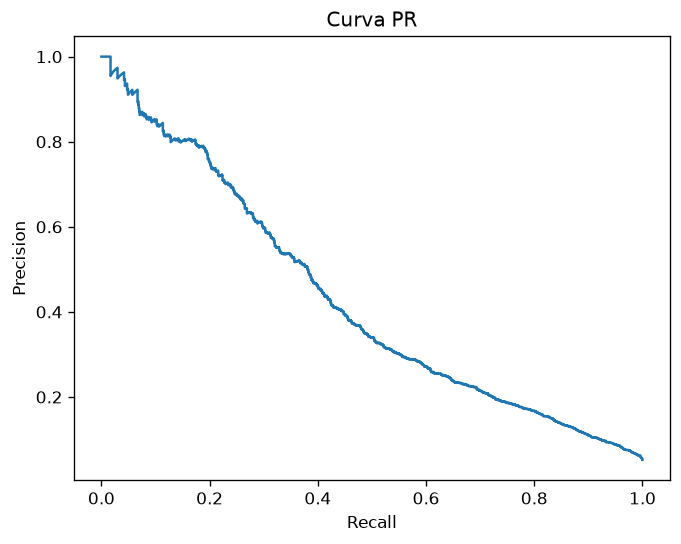

**roc_curve**

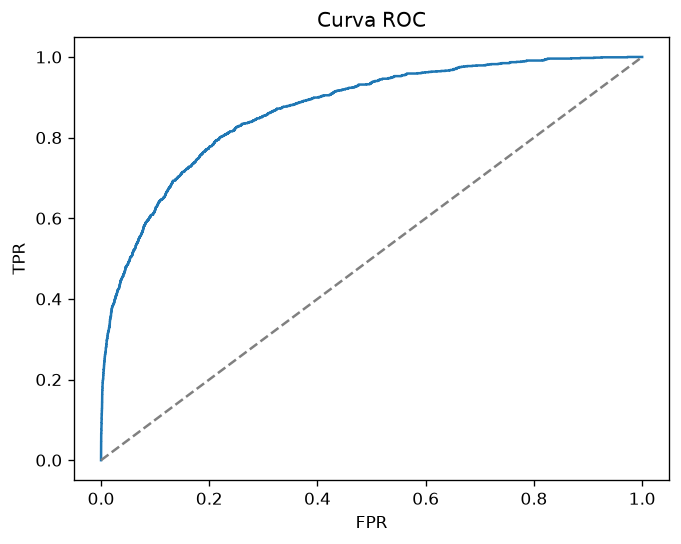

**reliability_diagram**

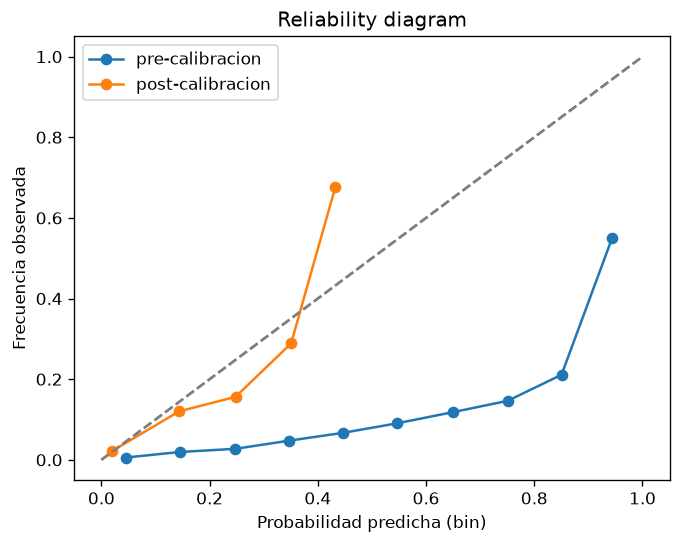

**economic_gain_curve**

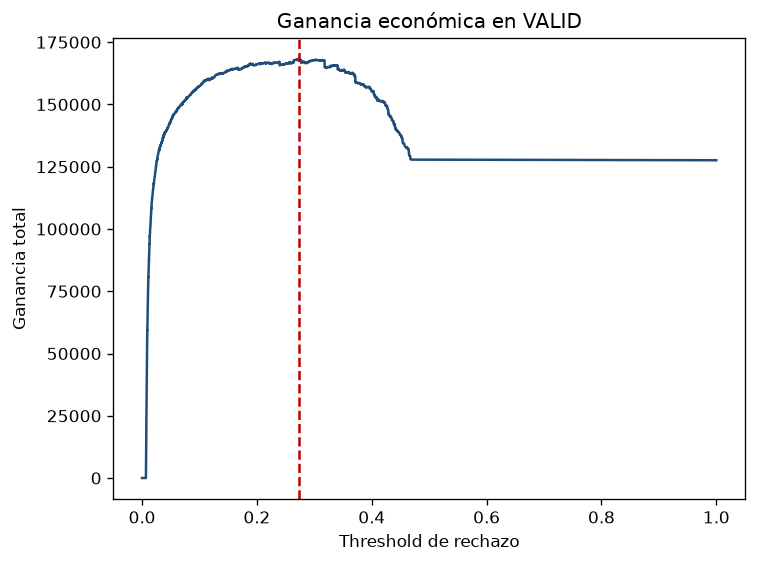

**candidate_comparison**

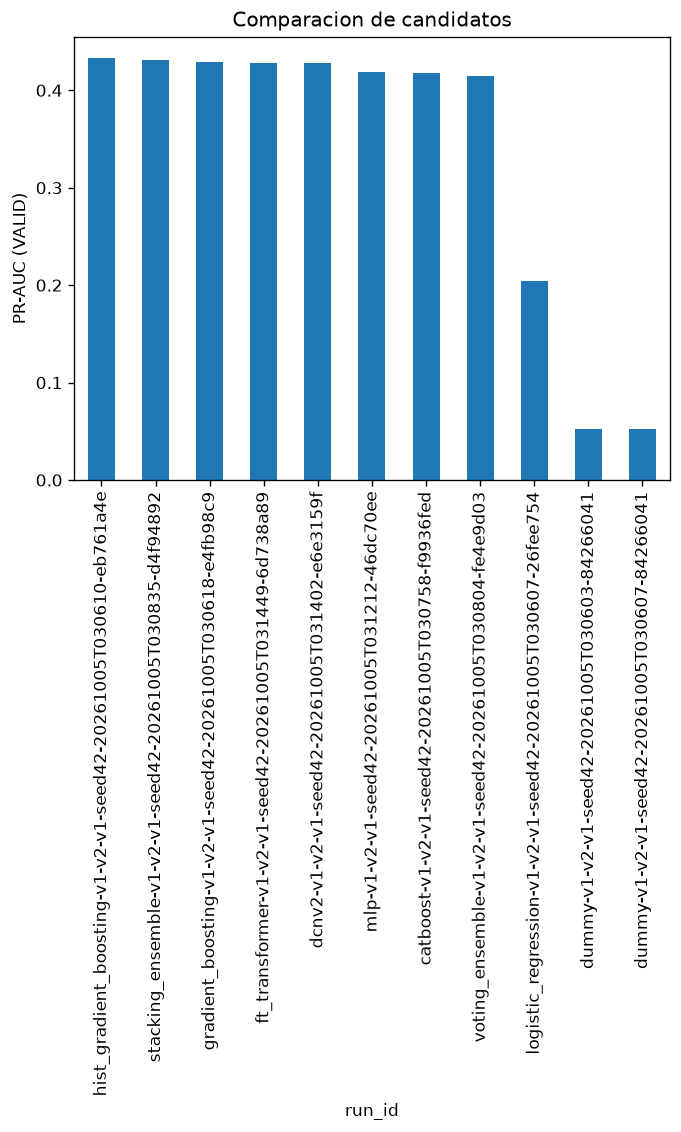

In [ ]:
def show_promoted(promoted_dir: Path):
    promoted_dir = Path(promoted_dir)

    display(Markdown('### COMPARACION DE CANDIDATOS (la que uso `promote_winner`)'))
    display(pd.read_csv(promoted_dir / 'candidate_comparison.csv').round(4))

    final_test = json.loads((promoted_dir / 'final_test_metrics.json').read_text())
    scalars = {k: v for k, v in final_test.items() if not isinstance(v, (dict, list))}
    display(Markdown('### METRICAS FINALES EN TEST (una sola evaluacion, umbral congelado)'))
    display(pd.Series(scalars, name='TEST').to_frame())
    if isinstance(final_test.get('economic'), dict):
        display(pd.Series(final_test['economic'], name='TEST economico').to_frame())

    threshold = json.loads((promoted_dir / 'threshold.json').read_text())
    contract = json.loads((promoted_dir / 'feature_contract.json').read_text())
    display(Markdown('### CONTRATOS DE SERVING'))
    print({k: threshold[k] for k in ('model', 'calibration_method', 'threshold', 'selected_on', 'seed', 'git_sha')})
    print(f"feature_contract: {len(contract['input_columns'])} columnas de entrada, "
          f"{len(contract['excluded_columns'])} excluidas, salida del preprocesador={contract['preprocessor_output_dim']}")

    for name, title in [
        ('temporal_stability.csv', 'Estabilidad temporal (VALID)'),
        ('segment_support.csv', 'Soporte por segmento'),
        ('threshold_table.csv', 'Tabla de umbrales (cada ~10 filas)'),
    ]:
        path = promoted_dir / name
        if path.exists():
            table = pd.read_csv(path)
            display(Markdown(f'### {title}'))
            display(table.iloc[::10] if name == 'threshold_table.csv' else table)

    for name in ('pr_curve', 'roc_curve', 'reliability_diagram', 'economic_gain_curve', 'candidate_comparison'):
        path = promoted_dir / f'{name}.png'
        if path.exists():
            display(Markdown(f'**{name}**'))
            display(Image(filename=str(path), width=520))

show_promoted(promoted_dir)

In [ ]:
# Model Card completo generado por la promocion
display(Markdown((promoted_dir / 'model_card.md').read_text()))

# Model Card — gradient_boosting (run `gradient_boosting-v1-v2-v1-seed42-20261005T030618-e4fb98c9`)

## 1. Resumen ejecutivo
Modelo 'gradient_boosting' seleccionado por mayor PR-AUC de validacion (0.4286); IC bootstrap 95%: [0.4012, 0.4593].

## 2. Dataset y ventana temporal
- Filas totales: 150000
- Ventana: 2020-04-07 23:59:56 a 2020-04-21 23:59:56
- Row counts / prevalencia por split: {'TRAIN': 97243, 'VALID': 23771, 'TEST': 28986} / {'TRAIN': 0.051623253087625845, 'VALID': 0.05224853813470195, 'TEST': 0.04271027392534327}

## 3. Features usadas y excluidas
(tabla incluir/excluir/investigar no provista)

## 4. Modelo ganador
- Modelo: `gradient_boosting` (model_version=v1, hyperparameters_version=v2, feature_version=v1)
- run_id ganador: `gradient_boosting-v1-v2-v1-seed42-20261005T030618-e4fb98c9`
- Criterio: mayor PR-AUC de validacion entre los candidatos comparados.

Hiperparametros de la corrida ganadora:
```json
{
  "parameters": {
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 1.0,
    "n_iter_no_change": 20,
    "class_weight": "balanced"
  }
}
```

## 5. Metricas train/valid/test
TEST se evalua una unica vez, con modelo/preprocesador/calibrador/umbral ya congelados.

| split | average_precision | roc_auc | brier |
|---|---|---|---|
| valid_at_best_epoch | 0.42859821627671324 | 0.8692924253149045 | 0.11023093398741993 |
| test (unica vez) | 0.3761042461163686 | 0.8549543980290653 | 0.03426181719362688 |

## 6. Calibracion (antes / despues)
- Metodo: `platt`
- Brier antes/despues: 0.11023093277534844 / 0.039898610802892504
- ECE antes/despues: 0.1927818993897037 / 0.012984975315368723
- Slope/Intercept (despues): 1.01093828789571 / 0.020779413572601435
- Reliability diagram: `/alloc/data/fury_ads-ctr-item-trigger-fda/fraud_challenge_2026/artifacts/promoted/gradient_boosting-v1-v2-v1-seed42-20261005T030618-e4fb98c9/reliability_diagram.png`

## 7. Umbral y politica de decision
- Umbral: 0.272646963596344
- Politica: `economic_profit` (defined_by=challenge_statement)
- Metricas en VALID al umbral: {'precision': 0.4015918958031838, 'recall': 0.4468599033816425, 'f1': 0.42301829268292684, 'fpr': 0.03670824270939678, 'profit_total': 168268.785, 'profit_per_transaction': 7.078742375163014, 'approved_count': 22389.0, 'approved_rate': 0.941861932606958, 'approved_amount': 832272.19, 'fraud_approved_amount': 31839.409999999996, 'legitimate_approved_amount': 800432.78, 'approve_all_profit': 127601.7175, 'reject_all_profit': 0.0, 'profit_uplift_vs_approve_all': 40667.067500000005}

## 8. Ganancia económica
- Ganancia VALID al threshold seleccionado: 168268.785
- Ganancia por transacción en VALID: 7.078742375163014
- Monto fraudulento aprobado en VALID: 31839.409999999996
- Ganancia TEST al threshold congelado: 221724.915
- Ganancia por transacción en TEST: 7.649379528048024
- Monto fraudulento aprobado en TEST: 44210.770000000004

## 9. Estabilidad temporal y por segmentos
- PR-AUC por ventana temporal: ver `/alloc/data/fury_ads-ctr-item-trigger-fda/fraud_challenge_2026/artifacts/promoted/gradient_boosting-v1-v2-v1-seed42-20261005T030618-e4fb98c9/temporal_stability.csv`
- Soporte por segmento: ver `/alloc/data/fury_ads-ctr-item-trigger-fda/fraud_challenge_2026/artifacts/promoted/gradient_boosting-v1-v2-v1-seed42-20261005T030618-e4fb98c9/segment_support.csv`

## 10. Latencia
- p50: 0.037850499893465894 ms, p95: 0.06386444993040641 ms

## 11. Limitaciones conocidas
- 'k' excluida por cardinalidad unica (id_like); revisar disponibilidad en inferencia si se reconsidera.
- 'score' requiere confirmar disponibilidad pre-decision antes de depender de ella en produccion.
- Ventana de datos ~45 dias; estabilidad temporal fuera de ese rango no esta validada.

## 12. Trazabilidad
- git_sha: `a6c5ff26a8069dee147d07e8d46df2cdf0d248d6`
- seed: 42
- feature_cache_id: `fb98053521f0507f`
- parquet/manifest hash: `b54b10e97e6021dc7c27d875cd79c32d51ca5a0a6c3a2e3941420522c60b9801`

## 13. Como reproducir
```bash
poetry install
poetry run ruff check .
poetry run mypy src
poetry run pytest
poetry run fraud-promote-winner --runs-dir artifacts/runs --config configs/promotion/v1.yml
```


___
___
## **🎯 11. Calibracion: Antes vs Despues**

PR-AUC y ROC-AUC miden si el modelo **ordena** bien los casos (*mas riesgoso primero*), no si el numero que devuelve es una probabilidad real. Un score sin calibrar puede ordenar perfecto y aun
asi decir 80% de riesgo en casos que en realidad son 30% -- eso rompe cualquier decision basada en el valor absoluto del score (*umbral, costo esperado, capacidad de revision manual*). Por eso el
umbral final (Seccion 7 del Model Card) se elige sobre la probabilidad **calibrada**, no sobre el score crudo del modelo.

In [ ]:
promoted_dir   = ARTIFACTS_ROOT / 'promoted' / winner_run_id
calib_metrics  = json.loads((promoted_dir / 'calibration_metrics.json').read_text())
threshold_info = json.loads((promoted_dir / 'threshold.json').read_text())

pre  = calib_metrics['pre_metrics']
post = calib_metrics['post_metrics']
print(f"Metodo de Calibracion: {calib_metrics['method']}")
print(f"Umbral Final (sobre probabilidad calibrada): {threshold_info['threshold']:.4f}\n")

comparison_calib = pd.DataFrame([
    {'Momento': 'Antes'  , 'brier': pre['brier'] , 'ece': pre['ece'] , 'slope': pre['slope'] , 'intercept': pre['intercept']},
    {'Momento': 'Despues', 'brier': post['brier'], 'ece': post['ece'], 'slope': post['slope'], 'intercept': post['intercept']},
])
display(comparison_calib)
print('(calibracion ideal: slope=1, intercept=0 -- despues debe quedar mucho mas cerca que antes)')

Metodo de calibracion: platt
Umbral final (sobre probabilidad calibrada): 0.2726



,momento,brier,ece,slope,intercept
0,antes,0.110231,0.192782,0.870665,-2.548954
1,despues,0.039899,0.012985,1.010938,0.020779


(calibracion ideal: slope=1, intercept=0 -- despues debe quedar mucho mas cerca que antes)


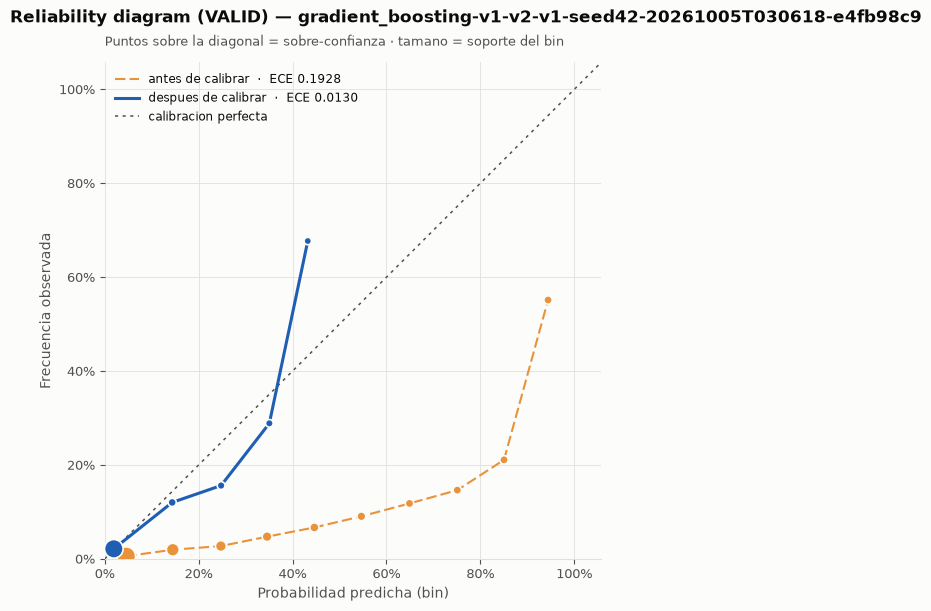

In [ ]:
fig = plot_reliability_comparison(
    pre, post,
    title = f'Reliability diagram (VALID) — {winner_run_id}',
)
save_figure(fig, ARTIFACTS_ROOT / 'reliability_pre_post.png')
plt.show()
plt.close(fig)

___
___
## **💰 12. Evaluacion Economica con economic_profit**

La politica del challenge asigna una ganancia de 25% sobre cada transaccion legitima aprobada y una perdida de 100% sobre cada fraude aprobado. El threshold se optimiza usando los montos de VALID y despues se congela para TEST.

In [ ]:
promoted_dir        = ARTIFACTS_ROOT / 'promoted' / winner_run_id
threshold_info      = json.loads((promoted_dir / 'threshold.json').read_text())
economic_valid_file = json.loads((promoted_dir / 'economic_metrics_valid.json').read_text())
final_test_metrics  = json.loads((promoted_dir / 'final_test_metrics.json').read_text())

economic_valid        = economic_valid_file.get('metrics', economic_valid_file)
economic_test         = final_test_metrics.get('economic', {})
selected_threshold    = float(threshold_info['threshold'])
policy_params         = economic_valid_file.get('policy', {}).get('params', {})
legitimate_gain_rate  = float(policy_params.get('legitimate_gain_rate', 0.25))
fraud_loss_rate       = float(policy_params.get('fraud_loss_rate', 1.0))
theoretical_threshold = legitimate_gain_rate / (legitimate_gain_rate + fraud_loss_rate)

economic_keys = [
    'profit_total', 'profit_per_transaction', 'approved_rate',
    'approved_amount', 'fraud_approved_amount', 'approve_all_profit',
    'profit_uplift_vs_approve_all',
]
summary_rows = []
for split, metrics in [('VALID', economic_valid), ('TEST', economic_test)]:
    summary_rows.append({'split': split, **{key: metrics.get(key) for key in economic_keys}})

display(pd.DataFrame(summary_rows))
print(f'THRESHOLD EMPIRICO SELECCIONADO EN VALID: {selected_threshold:.6f}')
print(f'THRESHOLD TEORICO DE REFERENCIA: {theoretical_threshold:.6f} (= {legitimate_gain_rate:.2f} / ({legitimate_gain_rate:.2f} + {fraud_loss_rate:.2f}))')
print('TEST USA EL THRESHOLD CONGELADO Y NO PARTICIPA EN LA SELECCION.')

,split,profit_total,profit_per_transaction,approved_rate,approved_amount,fraud_approved_amount,approve_all_profit,profit_uplift_vs_approve_all
0,VALID,168268.785,7.078742,0.941862,832272.19,31839.41,127601.7175,40667.0675
1,TEST,221724.915,7.649380,0.946250,1107953.51,44210.77,191247.2150,30477.7000


Threshold empirico seleccionado en VALID: 0.272647
Threshold teorico de referencia: 0.200000 (= 0.25 / (0.25 + 1.00))
TEST usa el threshold congelado y no participa en la seleccion.


,threshold,profit_total,profit_per_transaction,approved_rate,fraud_approved_amount,profit_uplift_vs_approve_all
seleccion_valid,0.272647,168268.785,7.078742,0.941862,31839.41,40667.0675
referencia_teorica,0.200000,166177.215,6.990754,0.914223,26233.83,38575.4975


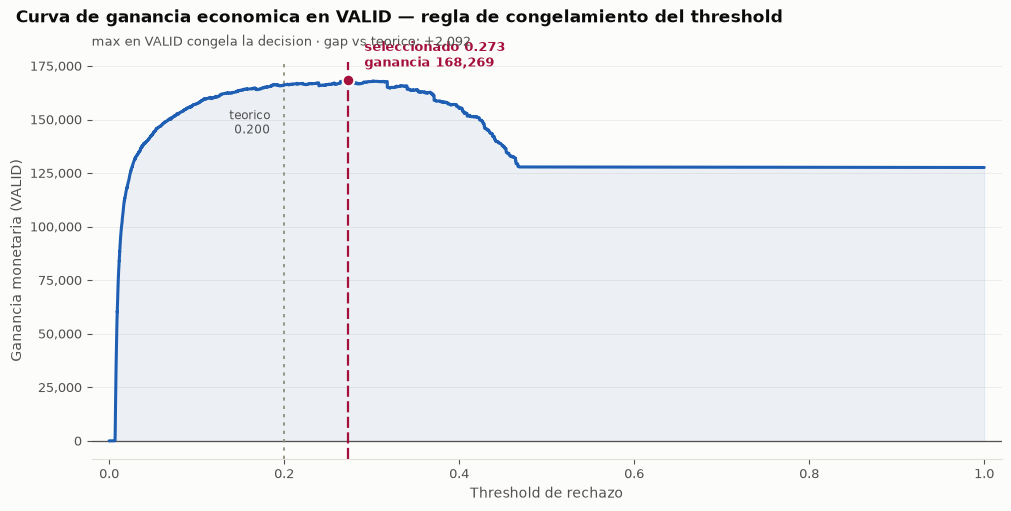

La curva muestra cuanto dinero se conserva al aprobar una transaccion por debajo del threshold.
El maximo de VALID es la regla usada para congelar la decision; el valor teorico solo sirve como referencia.


In [ ]:
curve = pd.read_csv(promoted_dir / 'economic_gain_curve.csv')
curve['threshold'] = pd.to_numeric(curve['threshold'])
curve = curve.sort_values('threshold').reset_index(drop=True)

selected_row = curve.iloc[(curve['threshold'] - selected_threshold).abs().argmin()]
theoretical_row = curve.iloc[(curve['threshold'] - theoretical_threshold).abs().argmin()]
view_columns = [
    column for column in [
        'threshold', 'profit_total', 'profit_per_transaction', 'approved_rate',
        'fraud_approved_amount', 'profit_uplift_vs_approve_all',
    ] if column in curve.columns
]

display(pd.DataFrame({
    'seleccion_valid': selected_row[view_columns],
    'referencia_teorica': theoretical_row[view_columns],
}).T)

# Costo de la discrepancia seleccionado vs teorico, en dinero (el numero que importa)
profit_gap = selected_row['profit_total'] - theoretical_row['profit_total']

fig = plot_economic_gain_curve(
    curve,
    selected_threshold    = selected_threshold,
    theoretical_threshold = theoretical_threshold,
)
save_figure(fig, ARTIFACTS_ROOT / 'curva_ganancia_economica.png')
plt.show()
plt.close(fig)

print('La curva muestra cuanto dinero se conserva al aprobar una transaccion por debajo del threshold.')
print('El maximo de VALID es la regla usada para congelar la decision; el valor teorico solo sirve como referencia.')

### **12.1 Como leer esta evaluacion**

- profit_total es la ganancia estimada con los montos reales del split: suma 0.25 por cada unidad monetaria legitima aprobada y resta 1.0 por cada unidad fraudulenta aprobada.
- fraud_approved_amount cuantifica directamente la exposicion monetaria que el modelo deja pasar.
- profit_uplift_vs_approve_all compara la politica del modelo contra aprobar todo. El baseline de rechazar todo tiene ganancia 0 y no aparece como una curva adicional.
- La referencia 0.20 supone que las probabilidades estan perfectamente calibradas y que el unico objetivo es el valor esperado por transaccion. El threshold empirico puede diferir porque usa scores calibrados, montos heterogeneos y una muestra finita.
- La decision final se juzga con TEST: debe conservar ganancia positiva y, sobre todo, superar el baseline de aprobar todo sin haber usado TEST para elegir el threshold.


___
___
## **🧪 13. Probar el scorer ONNX End2End**

Toma filas **crudas** (*como llegarian de una transaccion real, sin preprocesar*) y llama a `OnnxScorer.score()`: valida contra `feature_contract.json`, aplica el `preprocessor.pkl` **ya fiteado** (*los mismos imputadores/encoders/escaladores que se ajustaron una sola vez con TRAIN durante el entrenamiento — nada se reajusta acá*) y corre la cadena `model_raw.onnx -> calibrator.onnx` para devolver la probabilidad calibrada y la decision segun el umbral congelado. Es la misma ruta que usaria produccion.

In [ ]:
from pathlib import Path
from serving.onnx_scorer import OnnxScorer

promoted_dir = ARTIFACTS_ROOT / 'promoted' / winner_run_id
scorer       = OnnxScorer(promoted_dir)

def _to_native(value):
    # np.int64/np.float64 -> int/float de python (evita que la validacion del contrato
    # rechace un numpy scalar que no es instancia de int/float nativo); pd.NA/NaT/nan -> None
    # (asi el validador los reconoce como nulo, no como un valor con tipo incorrecto).
    if pd.isna(value):
        return None
    return value.item() if hasattr(value, 'item') else value

parquet_path = Path(manifest.output_parquet.path)
if not parquet_path.exists():
    parquet_path = DATA_ROOT / 'processed' / parquet_path.name
raw_df_for_test = pd.read_parquet(parquet_path)
sample = raw_df_for_test[raw_df_for_test['dataset_type'] == 'TEST'].sample(n = 30, random_state = 42)

for _, row in sample.iterrows():
    raw_features = {col: _to_native(val) for col, val in row.items()}
    true_label   = raw_features.pop('fraude')

    result = scorer.score(raw_features)  # preprocesamiento fiteado + ONNX, todo adentro
    print(
        f'fraude_real = {true_label} | fraud_probability = {result.fraud_probability:.4f} '
        f'| decision = {result.decision} | umbral = {result.threshold:.4f} '
        f'| latencia = {result.latency_ms:.2f}ms'
    )

fraude_real=0 | fraud_probability=0.0082 | decision=False | umbral=0.2726 | latencia=26.88ms
fraude_real=0 | fraud_probability=0.0193 | decision=False | umbral=0.2726 | latencia=24.36ms
fraude_real=0 | fraud_probability=0.0108 | decision=False | umbral=0.2726 | latencia=24.27ms
fraude_real=0 | fraud_probability=0.0080 | decision=False | umbral=0.2726 | latencia=24.15ms
fraude_real=0 | fraud_probability=0.0140 | decision=False | umbral=0.2726 | latencia=23.07ms
